In [59]:
!pip install -q torchmetrics albumentations opencv-python-headless matplotlib

In [60]:
import os
import cv2
import torch
import numpy as np

from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import ssd300_vgg16
from torchvision.transforms import functional as F
from torchvision.io import read_image

from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

In [61]:
# Paths
train_root = "/kaggle/input/railway-datasets/Railway_Train"
val_root   = "/kaggle/input/railway-datasets/Railway_Val"
test_root  = "/kaggle/input/railway-datasets/Railway_Test"

# SSD settings
IMG_SIZE = 640
NUM_CLASSES = 4  # background + 3 defects
BATCH_SIZE = 16
NUM_EPOCHS = 50
LR = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [62]:
class RailDefectsSSDDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        self.class_map = {"Bolt": 1, "Fastener": 2, "Railcrack": 3}

        for cls, cls_id in self.class_map.items():
            img_dir = os.path.join(root_dir, cls, "images")
            lbl_dir = os.path.join(root_dir, cls, "labels")

            if not os.path.isdir(img_dir):
                continue

            for img_name in os.listdir(img_dir):
                if img_name.lower().endswith((".jpg", ".png")):
                    img_path = os.path.join(img_dir, img_name)
                    lbl_path = os.path.join(lbl_dir, img_name.rsplit(".", 1)[0] + ".txt")
                    if os.path.exists(lbl_path):
                        self.samples.append((img_path, lbl_path, cls_id))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, lbl_path, cls_id = self.samples[idx]

        img = read_image(img_path).float() / 255.0
        if img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        h, w = img.shape[1:]

        # Resize to SSD300
        img = torch.nn.functional.interpolate(
            img.unsqueeze(0),
            size=(IMG_SIZE, IMG_SIZE),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        boxes, labels = [], []
        with open(lbl_path) as f:
            for line in f:
                _, xc, yc, bw, bh = map(float, line.split())

                xmin = (xc - bw / 2) * IMG_SIZE
                ymin = (yc - bh / 2) * IMG_SIZE
                xmax = (xc + bw / 2) * IMG_SIZE
                ymax = (yc + bh / 2) * IMG_SIZE

                # Clamp boxes (VERY IMPORTANT)
                xmin = max(0, xmin)
                ymin = max(0, ymin)
                xmax = min(IMG_SIZE, xmax)
                ymax = min(IMG_SIZE, ymax)

                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(cls_id)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }

        return img, target

In [63]:
def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    return tuple(zip(*batch))


train_ds = RailDefectsSSDDataset(train_root)
val_ds   = RailDefectsSSDDataset(val_root)
test_ds  = RailDefectsSSDDataset(test_root)

train_loader = DataLoader(
    dataset=train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

print("✅ Datasets ready")

✅ Datasets ready


In [64]:
model = ssd300_vgg16(weights=None, num_classes=NUM_CLASSES)
model.to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=0.9,
    weight_decay=5e-4
)

In [65]:
import torch
from torchvision.ops import box_iou

def compute_image_accuracy(outputs, targets, iou_threshold=0.5):
    """
    Returns fraction of images in batch where at least one predicted box
    matches a ground truth box with correct class and IoU >= threshold.
    """
    correct_images = 0
    total_images = len(targets)

    for pred, target in zip(outputs, targets):
        if len(target["boxes"]) == 0 or len(pred["boxes"]) == 0:
            continue  # skip if no objects

        ious = box_iou(pred["boxes"], target["boxes"])  # (num_pred, num_target)
        match = ((ious >= iou_threshold) & 
                 (pred["labels"].unsqueeze(1) == target["labels"].unsqueeze(0))).any()
        if match:
            correct_images += 1

    return correct_images / total_images if total_images > 0 else 0.0

In [66]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_map_50": []
}

metric = MeanAveragePrecision(iou_thresholds=[0.5])

for epoch in range(NUM_EPOCHS):
    # ---------------- TRAIN ----------------
    model.train()
    train_loss = 0.0
    train_correct, train_total = 0, 0

    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        images = [img.to(device) for img in images]
        targets_dev = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # forward + loss
        loss_dict = model(images, targets_dev)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        # compute train accuracy for this batch
        model.eval()
        with torch.no_grad():
            outputs = model(images)
            train_acc_batch = compute_image_accuracy(outputs, targets_dev)
            train_correct += train_acc_batch * len(targets)
            train_total += len(targets)
        model.train()

    train_loss /= len(train_loader)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_correct / train_total)

    # ---------------- VALIDATION ----------------
    model.eval()
    val_loss = 0.0
    val_correct, val_total = 0, 0
    metric.reset()

    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]"):
            images = [img.to(device) for img in images]
            targets_dev = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # loss (model must be in train mode for loss in some detectors)
            model.train()
            loss_dict = model(images, targets_dev)
            val_loss += sum(loss_dict.values()).item()
            model.eval()

            # predictions
            outputs = model(images)
            outputs_cpu = [{k: v.cpu() for k, v in o.items()} for o in outputs]
            metric.update(outputs_cpu, targets)

            # compute val accuracy for this batch
            val_acc_batch = compute_image_accuracy(outputs, targets_dev)
            val_correct += val_acc_batch * len(targets)
            val_total += len(targets)

    val_loss /= len(val_loader)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_correct / val_total)

    map_50 = metric.compute()["map_50"].item()
    history["val_map_50"].append(map_50)

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss={train_loss:.4f}, "
        f"Val Loss={val_loss:.4f}, "
        f"Train Acc={history['train_acc'][-1]:.4f}, "
        f"Val Acc={history['val_acc'][-1]:.4f}, "
        f"mAP@0.5={map_50:.4f}"
    )

Epoch 1/50 [Val]:   0%|          | 0/38 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
Epoch 1/50 [Val]: 100%|██████████| 38/38 [00:17<00:00,  2.17it/s]


Epoch 1: Train Loss=9.4449, Val Loss=8.1991, Train Acc=0.2244, Val Acc=0.2567, mAP@0.5=0.0345


Epoch 2/50 [Val]: 100%|██████████| 38/38 [00:17<00:00,  2.17it/s]


Epoch 2: Train Loss=7.9024, Val Loss=7.6654, Train Acc=0.2783, Val Acc=0.2633, mAP@0.5=0.0483


Epoch 3/50 [Val]: 100%|██████████| 38/38 [00:17<00:00,  2.17it/s]


...

Epoch 48: Train Loss=4.0425, Val Loss=4.2192, Train Acc=0.8950, Val Acc=0.8883, mAP@0.5=0.3911


Epoch 49/50 [Val]: 100%|██████████| 38/38 [00:17<00:00,  2.16it/s]


Epoch 49: Train Loss=4.0307, Val Loss=4.1904, Train Acc=0.8533, Val Acc=0.8983, mAP@0.5=0.3928


Epoch 50/50 [Val]: 100%|██████████| 38/38 [00:17<00:00,  2.17it/s]


Epoch 50: Train Loss=4.0158, Val Loss=4.1921, Train Acc=0.9067, Val Acc=0.7967, mAP@0.5=0.3907


In [67]:
model.eval()
metric.reset()

y_true, y_pred = [], []

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Testing"):
        images = [img.to(device) for img in images]
        outputs = model(images)

        for t, o in zip(targets, outputs):
            gt = t["labels"][0].item() if len(t["labels"]) else 0
            pr = o["labels"][0].item() if len(o["labels"]) else 0
            y_true.append(gt)
            y_pred.append(pr)

        outputs_cpu = [{k: v.cpu() for k, v in o.items()} for o in outputs]
        metric.update(outputs_cpu, targets)

test_map = metric.compute()["map"].item()
precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)
acc       = np.mean(np.array(y_true) == np.array(y_pred))

print("\nTEST RESULTS")
print("mAP@0.5:", test_map)
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Testing: 100%|██████████| 38/38 [00:09<00:00,  3.86it/s]



TEST RESULTS
mAP@0.5: 0.37334340810775757
Accuracy: 0.79
Precision: 0.7930158730158731
Recall: 0.79
F1-score: 0.7840101362052581


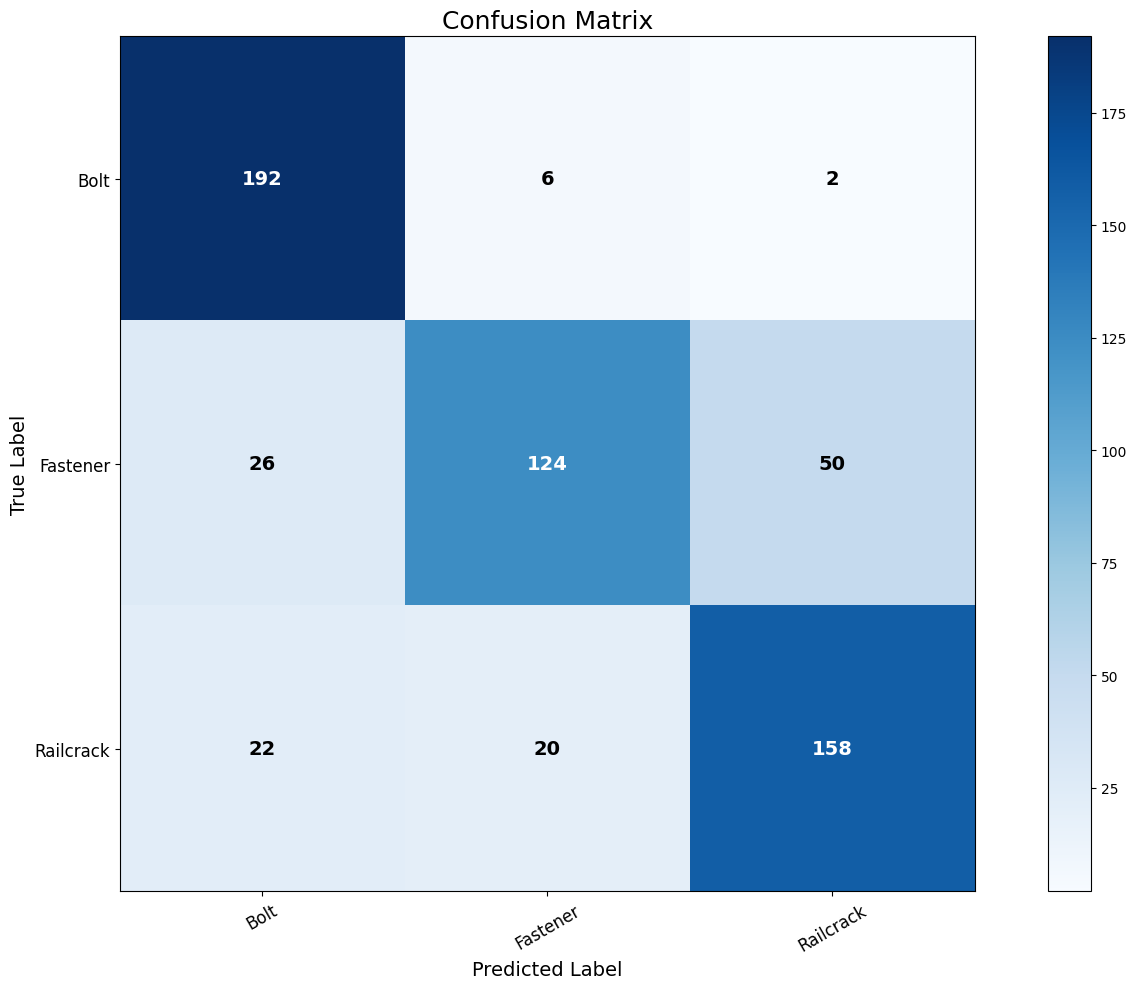

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

class_names = ["Bolt", "Fastener", "Railcrack"]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15, 10))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix", fontsize=18)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)

plt.xticks(range(len(class_names)), class_names, rotation=30, fontsize=12)
plt.yticks(range(len(class_names)), class_names, fontsize=12)

# ---- Add numbers inside cells ----
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=14,
            fontweight="bold"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

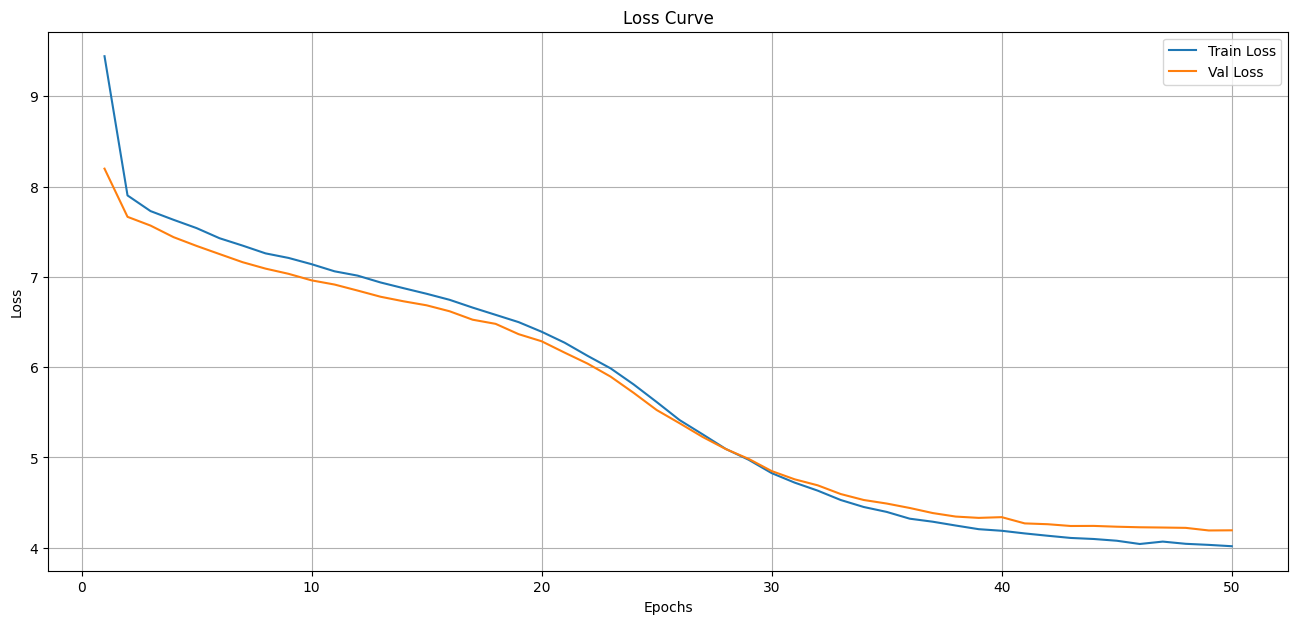

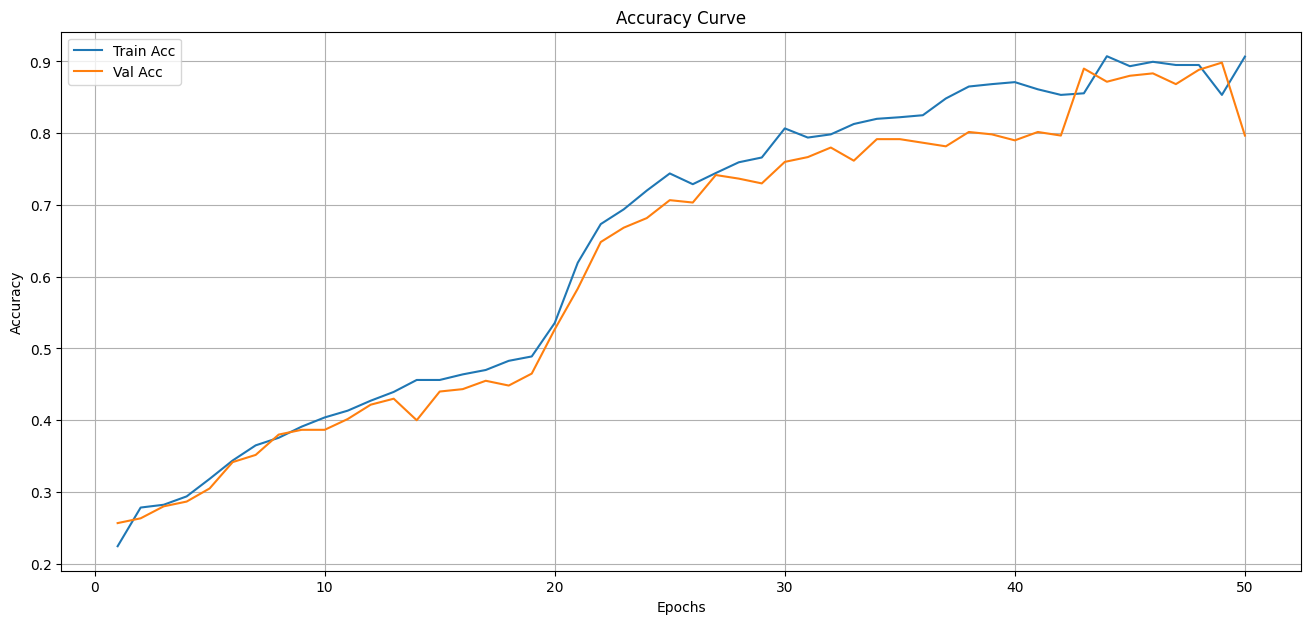

In [80]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

# --- Loss Curve ---
plt.figure(figsize=(16,7))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy Curve ---
plt.figure(figsize=(16,7))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()